<a href="https://colab.research.google.com/github/swastiksardaronlineclass-web/Lab-Assignment-N1/blob/main/Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BFS Traversal Order: ['A', 'B', 'C', 'D', 'E', 'F']
DFS Traversal Order: ['A', 'B', 'D', 'E', 'C', 'F']


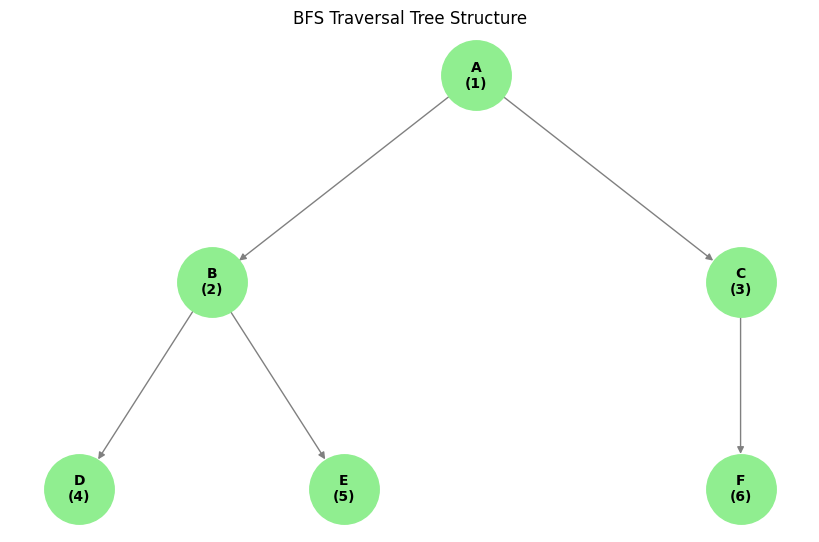

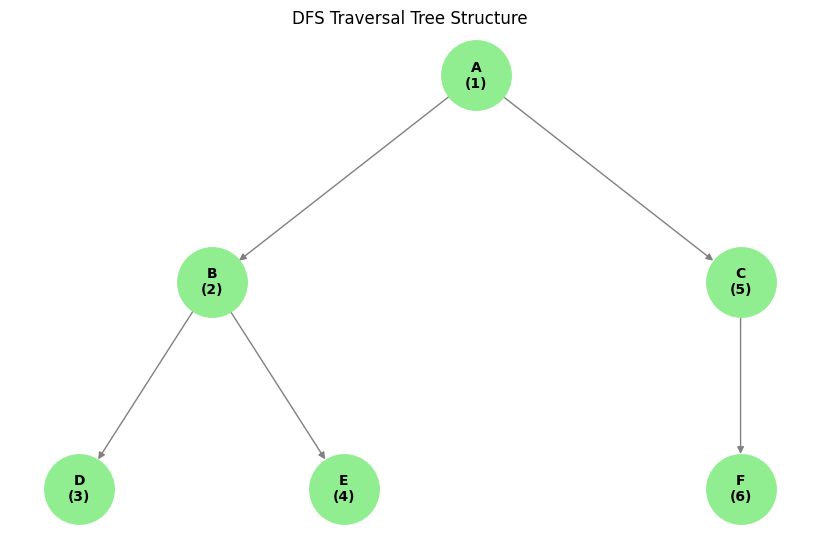

In [ ]:
import collections
import networkx as nx
import matplotlib.pyplot as plt

# 1. Define the graph using an adjacency list (Dictionary)
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': [],
    'F': []
}

def bfs(graph, start_node):
    visited = []
    queue = collections.deque([start_node])
    while queue:
        node = queue.popleft()
        if node not in visited:
            visited.append(node)
            queue.extend(graph[node])
    return visited

def dfs(graph, start_node, visited=None):
    if visited is None:
        visited = []
    if start_node not in visited:
        visited.append(start_node)
        for neighbor in graph[start_node]:
            dfs(graph, neighbor, visited)
    return visited

# 2 & 3. Perform traversals
bfs_order = bfs(graph, 'A')
dfs_order = dfs(graph, 'A')

print(f"BFS Traversal Order: {bfs_order}")
print(f"DFS Traversal Order: {dfs_order}")

# 4. Drawing tree diagrams with hierarchical layout
def hierarchy_pos(G, root, width=1., vert_gap=0.2, vert_loc=0, xcenter=0.5):
    pos = {root: (xcenter, vert_loc)}
    children = list(G.neighbors(root))
    if children:
        dx = width / len(children)
        nextx = xcenter - width/2 - dx/2
        for child in children:
            nextx += dx
            pos.update(hierarchy_pos(G, child, width=dx, vert_gap=vert_gap,
                                    vert_loc=vert_loc-vert_gap, xcenter=nextx))
    return pos

def draw_traversal_tree(graph, order, title):
    G = nx.DiGraph()
    for node, neighbors in graph.items():
        for neighbor in neighbors:
            G.add_edge(node, neighbor)

    # Calculate tree positions starting from root 'A'
    pos = hierarchy_pos(G, 'A')

    labels = {node: f"{node}\n({order.index(node)+1})" for node in G.nodes()}

    plt.figure(figsize=(8, 5))
    nx.draw(G, pos, with_labels=True, labels=labels, node_size=2500,
            node_color='lightgreen', font_size=10, font_weight='bold',
            arrows=True, edge_color='gray')
    plt.title(title)
    plt.show()

draw_traversal_tree(graph, bfs_order, "BFS Traversal Tree Structure")
draw_traversal_tree(graph, dfs_order, "DFS Traversal Tree Structure")